In [1]:
import numpy as np


def thomas_solve(a, b, c, d):
    """Solve tridiagonal system A x = d using the Thomas algorithm.

    A has subdiagonal a, diagonal b, superdiagonal c.
    a, b, c, d are 1D numpy arrays (a[0] unused, c[-1] unused).
    Returns x (1D array).
    """
    n = len(d)
    ac = a.copy().astype(float)
    bc = b.copy().astype(float)
    cc = c.copy().astype(float)
    dc = d.copy().astype(float)

    # Forward elimination
    for i in range(1, n):
        m = ac[i] / bc[i - 1]
        bc[i] = bc[i] - m * cc[i - 1]
        dc[i] = dc[i] - m * dc[i - 1]

    # Back substitution
    x = np.zeros(n, dtype=float)
    x[-1] = dc[-1] / bc[-1]
    for i in range(n - 2, -1, -1):
        x[i] = (dc[i] - cc[i] * x[i + 1]) / bc[i]

    return x


def adi_diffusion(u0, D, Lx, Ly, Nx, Ny, dt, T, bc_func=None, source_func=None, save_steps=None):
    """
    ADI (Peaceman-Rachford) solver for u_t = D (u_xx + u_yy) + s.

    Parameters
    ----------
    u0 : callable or 2D array
        Initial condition. If callable, called as u0(X, Y) where X,Y are meshgrid arrays (Ny,Nx).
    D : float
        Diffusion coefficient (scalar).
    Lx, Ly : floats
        Domain size in x and y.
    Nx, Ny : ints
        Number of cells in x and y (uniform grid, cell-centred).
    dt : float
        Time step.
    T : float
        Final time.
    bc_func : callable or None
        Boundary condition function. If None, zero Dirichlet is used.
        Should have signature bc_func(side, coord, t) where side in {'left','right','bottom','top'}
        and coord is the coordinate along the boundary (y for left/right, x for bottom/top).
    source_func : callable or None
        Source term function s(x,y,t). If None, no source.
    save_steps : list of floats or None
        Times at which to save snapshots.

    Returns
    -------
    x, y : 1D arrays
        Cell-center coordinates in x and y.
    snapshots : dict
        Mapping time -> 2D array (Ny,Nx) for saved times.
    u : 2D array
        Final solution at time T.
    """
    # grid (cell centers)
    dx = Lx / Nx
    dy = Ly / Ny
    x = (np.arange(Nx) + 0.5) * dx
    y = (np.arange(Ny) + 0.5) * dy

    X, Y = np.meshgrid(x, y)

    # initial condition
    if callable(u0):
        u = u0(X, Y)
    else:
        u = np.array(u0, dtype=float)

    nt = int(np.ceil(T / dt))

    # ADI factors
    r_x = D * dt / (2.0 * dx * dx)
    r_y = D * dt / (2.0 * dy * dy)

    nx = Nx
    ny = Ny

    # tridiagonal coefficients for constant-coefficient problems
    ax = np.zeros(nx)
    bx = np.zeros(nx)
    cx = np.zeros(nx)
    ay = np.zeros(ny)
    by = np.zeros(ny)
    cy = np.zeros(ny)

    bx[:] = 1.0 + 2.0 * r_x
    ax[1:] = -r_x
    cx[:-1] = -r_x

    by[:] = 1.0 + 2.0 * r_y
    ay[1:] = -r_y
    cy[:-1] = -r_y

    if bc_func is None:
        def bc_func(side, coord, t):
            return 0.0

    snapshots = {}
    current_time = 0.0
    if save_steps is None:
        save_steps = []
    save_times = set(save_steps)

    # time-stepping
    for n in range(nt):
        t = current_time

        # First half-step: implicit in x, explicit in y (using u^n)
        u_star = np.zeros_like(u)
        for j in range(ny):
            RHS = np.zeros(nx, dtype=float)
            for i in range(nx):
                uij = u[j, i]

                # discrete second derivative in y at time t (explicit)
                if j == 0:
                    u_jm1 = bc_func('bottom', x[i], t)
                else:
                    u_jm1 = u[j - 1, i]
                if j == ny - 1:
                    u_jp1 = bc_func('top', x[i], t)
                else:
                    u_jp1 = u[j + 1, i]

                lap_y = (u_jm1 - 2.0 * uij + u_jp1) / (dy * dy)
                s_val = 0.0 if source_func is None else source_func(x[i], y[j], t)

                # RHS for the x-implicit solve
                RHS[i] = uij + 0.5 * dt * (D * lap_y + s_val)

            # adjust RHS for Dirichlet boundary values (ghosts moved to RHS)
            gL = bc_func('left', y[j], t)
            gR = bc_func('right', y[j], t)
            RHS[0] += r_x * gL
            RHS[-1] += r_x * gR

            # solve tridiagonal for this row
            u_row = thomas_solve(ax, bx, cx, RHS)
            u_star[j, :] = u_row

        # Second half-step: implicit in y, explicit in x (using u_star)
        u_new = np.zeros_like(u)
        for i in range(nx):
            RHS = np.zeros(ny, dtype=float)
            for j in range(ny):
                uij_star = u_star[j, i]

                # discrete second derivative in x at time t+dt/2 (explicit)
                if i == 0:
                    u_im1 = bc_func('left', y[j], t + 0.5 * dt)
                else:
                    u_im1 = u_star[j, i - 1]
                if i == nx - 1:
                    u_ip1 = bc_func('right', y[j], t + 0.5 * dt)
                else:
                    u_ip1 = u_star[j, i + 1]

                lap_x = (u_im1 - 2.0 * uij_star + u_ip1) / (dx * dx)
                s_val = 0.0 if source_func is None else source_func(x[i], y[j], t + 0.5 * dt)

                RHS[j] = uij_star + 0.5 * dt * (D * lap_x + s_val)

            # adjust RHS for Dirichlet at bottom/top
            gB = bc_func('bottom', x[i], t + 0.5 * dt)
            gT = bc_func('top', x[i], t + 0.5 * dt)
            RHS[0] += r_y * gB
            RHS[-1] += r_y * gT

            # solve tridiagonal for this column
            u_col = thomas_solve(ay, by, cy, RHS)
            for j in range(ny):
                u_new[j, i] = u_col[j]

        current_time += dt
        u = u_new

        # save snapshots
        if np.isclose(current_time, np.array(save_steps)).any() or current_time in save_times:
            snapshots[round(current_time, 10)] = u.copy()

    return x, y, snapshots, u

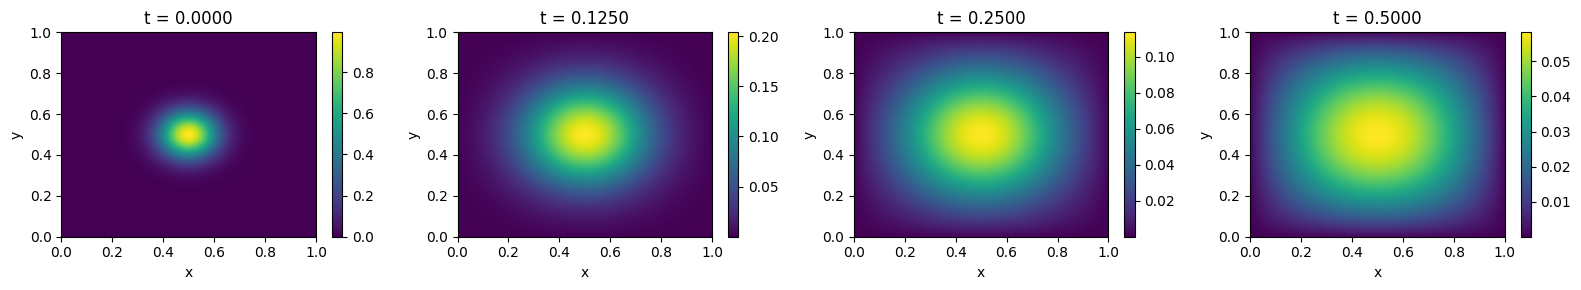

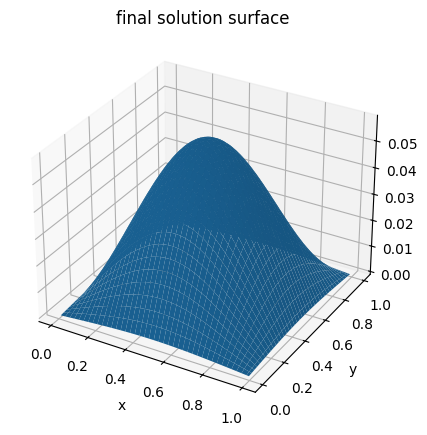

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def gaussian_ic(X, Y, x0=0.5, y0=0.5, sigma=0.08):
    return np.exp(-((X - x0) ** 2 + (Y - y0) ** 2) / (2.0 * sigma ** 2))

# domain and solver parameters
Lx = 1.0
Ly = 1.0
Nx = 80
Ny = 80
D = 0.1
dt = 5e-4
T = 0.5
save_times = [0.0, T * 0.25, T * 0.5, T]

x, y, snaps, u_final = adi_diffusion(
    gaussian_ic, D, Lx, Ly, Nx, Ny, dt, T, bc_func=None, source_func=None, save_steps=save_times
)

# plot snapshots
fig, axes = plt.subplots(1, len(save_times), figsize=(4 * len(save_times), 3))
for ax, t in zip(axes, save_times):
    key = round(t, 10)
    if key == 0.0:
        u = gaussian_ic(*np.meshgrid(x, y))
    else:
        u = snaps.get(round(t, 10), None)
        if u is None:
            ks = sorted(list(snaps.keys()))
            u = snaps[ks[-1]]
    im = ax.imshow(u, origin='lower', extent=[0, Lx, 0, Ly], aspect='auto')
    ax.set_title(f"t = {t:.4f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# final 3D surface
Xc, Yc = np.meshgrid(x, y)
fig2 = plt.figure(figsize=(6, 5))
ax3 = fig2.add_subplot(111, projection='3d')
ax3.plot_surface(Xc, Yc, u_final, linewidth=0, antialiased=True)
ax3.set_title("final solution surface")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("u")
plt.show()

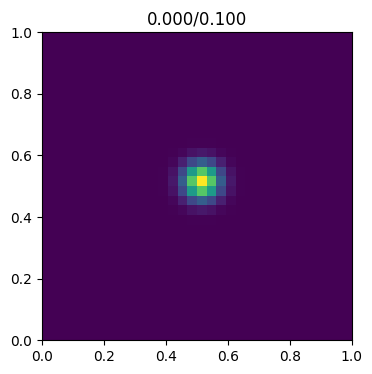

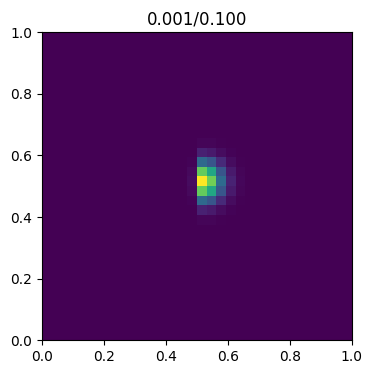

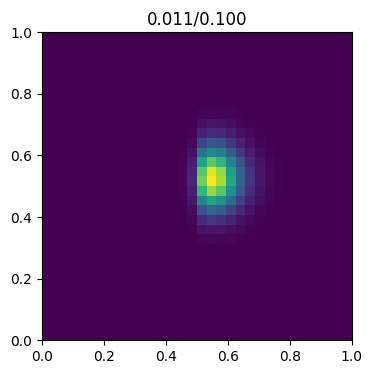

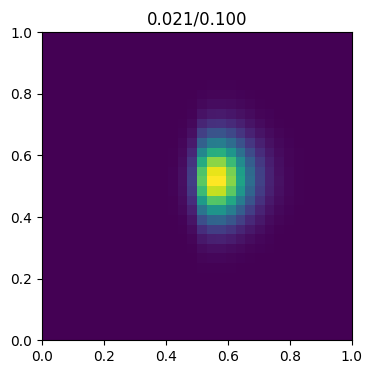

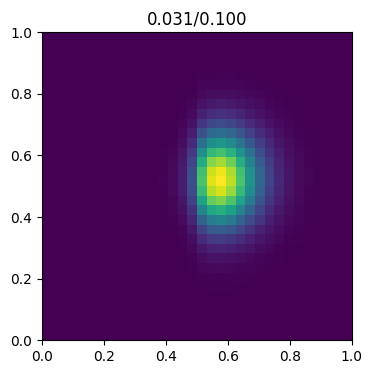

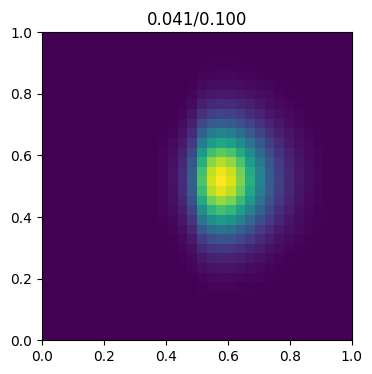

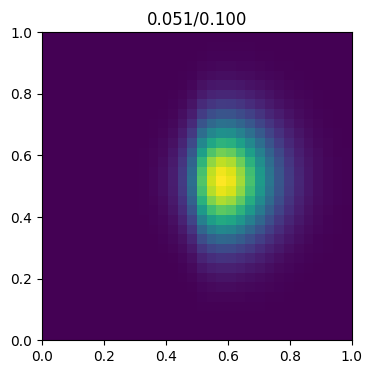

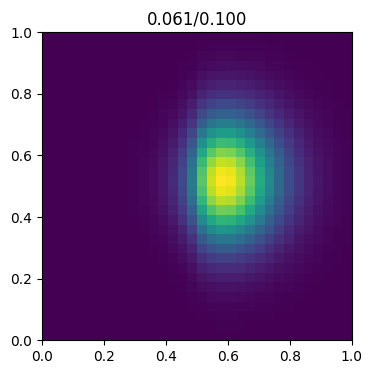

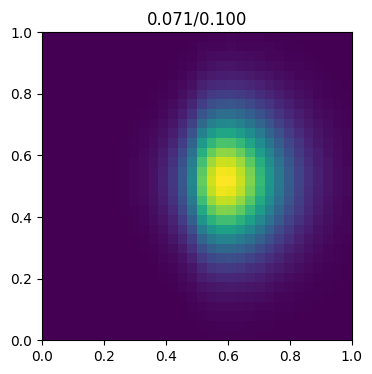

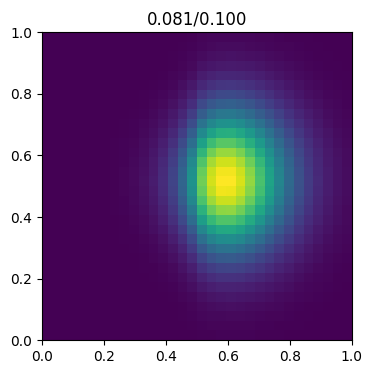

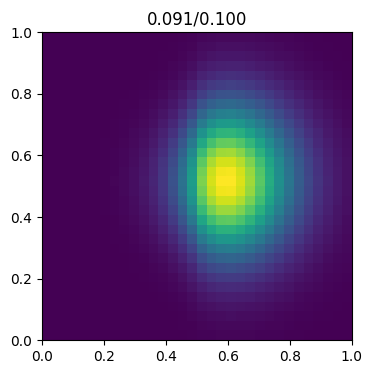

max u: 0.015449267413271501 min u: 8.59074379825165e-11


In [67]:
import numpy as np

def thomas_tridiag(a, b, c, d):
    """
    Solve tridiagonal system with vectors a (sub, length n), b (diag), c (super) and rhs d.
    a[0] is unused (can be 0). Returns solution x.
    Operates on 1D numpy arrays.
    """
    n = b.size
    # forward eliminate
    for i in range(1, n):
        m = a[i] / b[i-1]
        b[i] -= m * c[i-1]
        d[i] -= m * d[i-1]
    d[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        d[i] = (d[i] - c[i] * d[i+1]) / b[i]

def harmonic_mean(a, b):
    """Harmonic mean of a and b, handling zeros robustly."""
    eps = 1e-16
    a = np.asarray(a)
    b = np.asarray(b)
    denom = (1.0/(a+eps) + 1.0/(b+eps))
    return 2.0 / denom

def adi_diffusion_3d_varD(u0_func, D_func, Lx, Ly, Lz, Nx, Ny, Nz,
                          dt, T):
    """
    3D ADI solver with spatially varying D.
    Parameters:
        u0_func(x,y,z) -> initial field
        D_func(x,y,z) -> diffusion coefficient (>=0)
        Lx,Ly,Lz -> domain sizes
        Nx,Ny,Nz -> number of cells (uniform)
        dt, T -> timestep and final time
        bc_type -> 'dirichlet' or 'neumann' (applies same type on all faces)
        bc_value -> scalar (Dirichlet value or Neumann flux value; for Neumann we assume zero flux if 0.0)
        source_func(x,y,z,t) -> optional source term; if None, zero source
        save_times -> list of times to store snapshots (optional)

    Returns:
        x,y,z arrays (cell centers), snapshots dict time->u array, final u (Nz,Ny,Nx)
    """
    dx = Lx / Nx
    dy = Ly / Ny
    dz = Lz / Nz

    # initial condition
    u = np.zeros((Nz, Ny, Nx), dtype=float)
    u_new = np.zeros((Nz, Ny, Nx), dtype=float)
    for k in range(Nz):
        for j in range(Ny):
            for i in range(Nx):
                x = dx * i
                y = dy * j
                z = dz * k
                u[k,j,i] = u0_func(x, y, z)

    # precompute D at cell centers
    Dcc = np.zeros_like(u)
    for k in range(Nz):
        for j in range(Ny):
            for i in range(Nx):
                x = dx * i
                y = dy * j
                z = dz * k
                Dcc[k,j,i] = D_func(x, y, z)

    nt = int(np.ceil(T / dt))
    rfac_x = dt / (2.0 * dx * dx)
    rfac_y = dt / (2.0 * dy * dy)
    rfac_z = dt / (2.0 * dz * dz)

    tcur = 0.0

    fg, ax = plt.subplots(figsize=(4, 4))
    ax.axis('equal')
    im = ax.imshow(u[:, :, 0], origin='lower', extent=[0, Lx, 0, Ly], aspect='auto')
    ax.set_title(f"{tcur:.3f}/{T:.3f}")
    plt.show()

    ln = max(Nx, max(Ny, Nz))
    a = np.zeros(ln)  # subdiagonal (a[0] unused)
    b = np.zeros(ln)
    c = np.zeros(ln)  # superdiagonal (c[-1] unused)
    RHS = np.zeros(ln)
    
    # Time loop
    for step in range(nt):
        t = tcur
        # ---- STEP 1: X-implicit, explicit in y,z. Solve for u_star (k,j) lines in x ----
        # For each fixed (k,j) solve tridiagonal in i
        for k in range(Nz):
            for j in range(Ny):
                # build tridiagonal coefficients a,b,c and RHS for i=0..Nx-1
                for i in range(Nx):
                    u_ijk = u[k,j,i]
                    # y-neighbors
                    if j == 0:
                        u_jm = u_ijk
                    else:
                        u_jm = u[k,j-1,i]
                    if j == Ny-1:
                        u_jp = u_ijk
                    else:
                        u_jp = u[k,j+1,i]
                    lap_y = rfac_y*(u_jm - 2.0*u_ijk + u_jp)
                    # z-neighbors
                    if k == 0:
                        u_km = u_ijk
                    else:
                        u_km = u[k-1,j,i]
                    if k == Nz-1:
                        u_kp = u_ijk
                    else:
                        u_kp = u[k+1,j,i]
                    lap_z = rfac_z*(u_km - 2.0*u_ijk + u_kp)

                    s = 0.0 
                    RHS[i] = u_ijk + Dcc[k,j,i]*(lap_y + lap_z) + 0.5*dt*s

                    # left face D_{i-1/2}
                    if i == 0:
                        D_imh = Dcc[k,j,0]
                    else:
                        D_imh = Dcc[k,j,i-1]
                    if i < Nx-1:
                        D_iph = Dcc[k,j,i]
                    else:
                        D_iph = Dcc[k,j,-1]
                    ai = rfac_x * D_imh
                    ci = rfac_x * D_iph
                    a[i] = -ai
                    c[i] = -ci
                    b[i] = 1.0 + ai + ci

                # solve tridiagonal
                thomas_tridiag(a, b, c, RHS)
                u_new[k,j,:] = RHS[0:Nx]

        # ---- STEP 2: Y-implicit, explicit in x,z. Solve for u_dblstar along j ----
        for k in range(Nz):
            for i in range(Nx):
                for j in range(Ny):
                    u_ijk = u_new[k,j,i]
                    # x-neighbors explicit
                    if i == 0:
                        u_im = u_ijk
                    else:
                        u_im = u_new[k,j,i-1]
                    if i == Nx-1:
                        u_ip = u_ijk
                    else:
                        u_ip = u_new[k,j,i+1]
                    lap_x = rfac_x * (u_im - 2.0*u_ijk + u_ip)
                    # z-neighbors explicit
                    if k == 0:
                        u_km = u_ijk
                    else:
                        u_km = u_new[k-1,j,i]
                    if k == Nz-1:
                        u_kp = u_ijk
                    else:
                        u_kp = u_new[k+1,j,i]
                    lap_z = rfac_z*(u_km - 2.0*u_ijk + u_kp)
                    s = 0.0
                    RHS[j] = u_ijk + Dcc[k,j,i]*(lap_x + lap_z) + 0.5*dt*s

                    if j == 0:
                        D_jmh = Dcc[k,j,i]
                    else:
                        D_jmh = Dcc[k,j-1,i]
                    if j < Ny-1:
                        D_jph = Dcc[k,j,i]
                    else:
                        D_jph = Dcc[k,j,i]
                    aj = rfac_y * D_jmh
                    cj = rfac_y * D_jph
                    a[j] = -aj
                    c[j] = -cj
                    b[j] = 1.0 + aj + cj

                thomas_tridiag(a, b, c, RHS)
                u[k, :, i] = RHS[0:Ny]

        # ---- STEP 3: Z-implicit, explicit in x,y. Solve for u^{n+1} along k ----
        u_new = np.zeros_like(u)
        for j in range(Ny):
            for i in range(Nx):
                for k in range(Nz):
                    u_ijk = u[k,j,i]
                    # x neighbors explicit
                    if i == 0:
                        u_im = u_ijk
                    else:
                        u_im = u[k,j,i-1]
                    if i == Nx-1:
                        u_ip = u_ijk
                    else:
                        u_ip = u[k,j,i+1]
                    lap_x = (u_im - 2.0*u_ijk + u_ip)*rfac_x
                    # y neighbors explicit
                    if j == 0:
                        u_jm = u_ijk
                    else:
                        u_jm = u[k,j-1,i]
                    if j == Ny-1:
                        u_jp = u_ijk
                    else:
                        u_jp = u[k,j+1,i]
                    lap_y = (u_jm - 2.0*u_ijk + u_jp)*rfac_y
                    s = 0.0 
                    RHS[k] = u_ijk + Dcc[k,j,i]*(lap_x + lap_y) + 0.5*rfac_y*s

                    if k == 0:
                        D_kmh = Dcc[k,j,i]
                    else:
                        D_kmh = Dcc[k-1,j,i]
                    if k < Nz-1:
                        D_kph = Dcc[k,j,i]
                    else:
                        D_kph = Dcc[k,j,i]
                    aik = rfac_z * D_kmh
                    cik = rfac_z * D_kph
                    a[k] = -aik
                    c[k] = -cik
                    b[k] = 1.0 + aik + cik

                thomas_tridiag(a, b, c, RHS)
                u_new[:,j,i] = RHS[0:Nz]

        tcur += dt
        u = u_new
        if step % 10 == 0:
            fg, ax = plt.subplots(figsize=(4, 4))
            ax.axis('equal')
            im = ax.imshow(u[:, :, 0], origin='lower', extent=[0, Lx, 0, Ly], aspect='auto')
            ax.set_title(f"{tcur:.3f}/{T:.3f}")
            plt.show()
        

# ---------------- Example usage ----------------
if __name__ == "__main__":
    # domain
    Lx = Ly = Lz = 1.0
    Nx = Ny = Nz = 32   # keep moderate for example
    dt = 1e-3
    T = 0.1

    # initial condition: gaussian centered at 0.5,0.5,0.5
    def u0(x,y,z):
        x0,y0,z0 = 0.5,0.5,0.5
        sig = 0.04
        return np.exp(-((x-x0)**2 + (y-y0)**2 + (z-z0)**2)/(2*sig*sig))

    def Dfunc(x,y,z):
        return 0.05 if (x < 0.5 and y < 0.5) else 0.1

    # zero source
    source = None

    # Neumann BC (zero flux) implemented by mirroring interior value; pass bc_type='neumann'
    adi_diffusion_3d_varD(u0, Dfunc, Lx, Ly, Lz, Nx, Ny, Nz, dt, T)

    print("max u:", np.max(u_final), "min u:", np.min(u_final))


In [ ]:
out-xy-50.000000.csv

In [18]:
import matplotlib.pyplot as plt
import numpy as np

In [24]:
%ls build

"build": No such file or directory (os error 2)


IndexError: index 10 is out of bounds for axis 0 with size 10

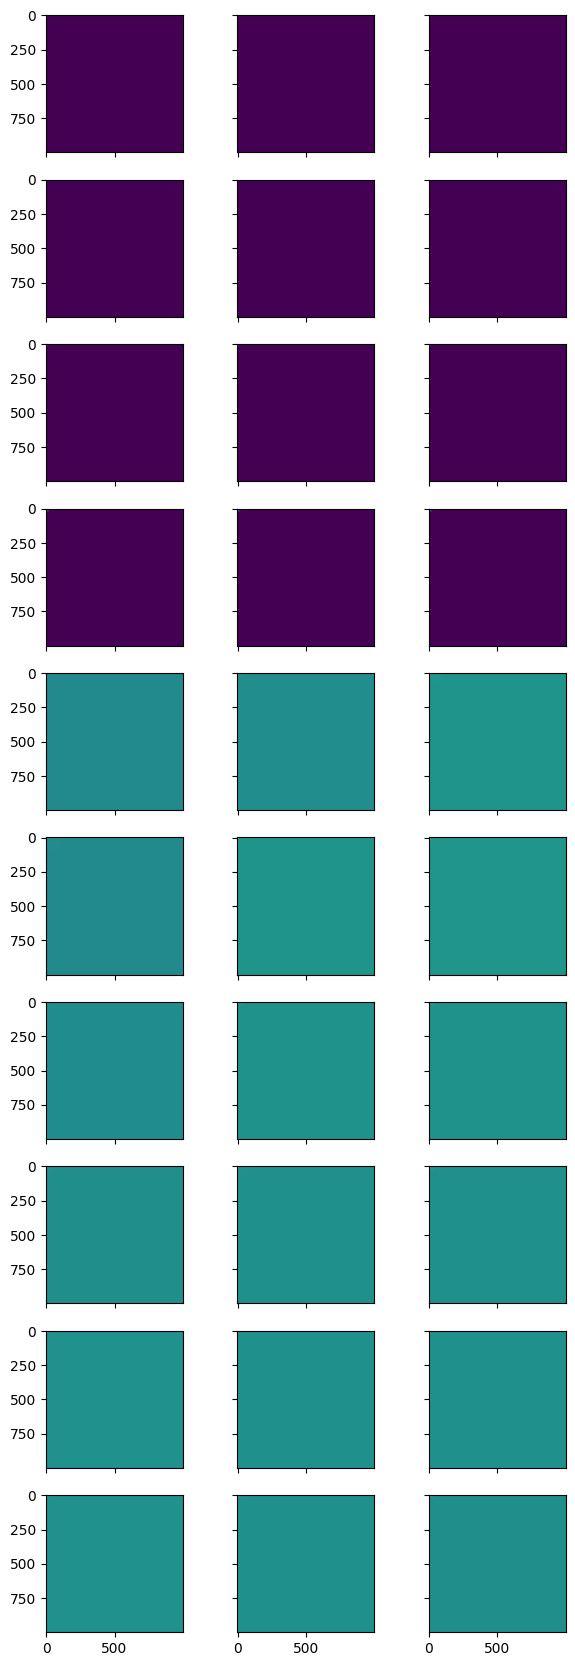

In [26]:
fg, axs = plt.subplots(10, 3, sharex=True, sharey=True, figsize=(7, 21))
for ix, t in enumerate(range(0, 301, 25)):
    im = np.loadtxt(f'../build/out-xy-{float(t):.6f}.csv', delimiter=",")
    axs[ix, 0].imshow(im)
    im = np.loadtxt(f'../build/out-xz-{float(t):.6f}.csv', delimiter=",")
    axs[ix, 1].imshow(im)
    im = np.loadtxt(f'../build/out-yz-{float(t):.6f}.csv', delimiter=",")
    axs[ix, 2].imshow(im)    

In [1]:
import arbor as A

In [8]:
mrf = A.load_asc('../cell1.asc')
cell = A.cable_cell(mrf.morphology, A.decor(), A.label_dict())
cell.cv

Docstring:
discretization(*args, **kwargs)
Overloaded function.

1. discretization(self: arbor._arbor.cable_cell) -> Optional[arbor._arbor.cv_policy]

The cv_policy used to discretise the cell into compartments for simulation

2. discretization(self: arbor._arbor.cable_cell, policy: arbor._arbor.cv_policy) -> None

A cv_policy used to discretise the cell into compartments for simulation

3. discretization(self: arbor._arbor.cable_cell, policy: str) -> None

An s-expression string representing a cv_policy used to discretise the cell into compartments for simulation
Type:      method

In [14]:
cvp = A.cell_cv_data(cell)

TypeError: arbor._arbor.cell_cv_data: No constructor defined!

In [13]:
cell.cables('(all)')

[(cable 0 0 1),
 (cable 1 0 1),
 (cable 2 0 1),
 (cable 3 0 1),
 (cable 4 0 1),
 (cable 5 0 1),
 (cable 6 0 1),
 (cable 7 0 1),
 (cable 8 0 1),
 (cable 9 0 1),
 (cable 10 0 1),
 (cable 11 0 1),
 (cable 12 0 1),
 (cable 13 0 1),
 (cable 14 0 1),
 (cable 15 0 1),
 (cable 16 0 1),
 (cable 17 0 1),
 (cable 18 0 1),
 (cable 19 0 1),
 (cable 20 0 1),
 (cable 21 0 1),
 (cable 22 0 1),
 (cable 23 0 1),
 (cable 24 0 1),
 (cable 25 0 1),
 (cable 26 0 1),
 (cable 27 0 1),
 (cable 28 0 1),
 (cable 29 0 1),
 (cable 30 0 1),
 (cable 31 0 1),
 (cable 32 0 1),
 (cable 33 0 1),
 (cable 34 0 1),
 (cable 35 0 1),
 (cable 36 0 1),
 (cable 37 0 1),
 (cable 38 0 1),
 (cable 39 0 1),
 (cable 40 0 1),
 (cable 41 0 1),
 (cable 42 0 1),
 (cable 43 0 1),
 (cable 44 0 1),
 (cable 45 0 1),
 (cable 46 0 1),
 (cable 47 0 1),
 (cable 48 0 1),
 (cable 49 0 1),
 (cable 50 0 1),
 (cable 51 0 1),
 (cable 52 0 1),
 (cable 53 0 1),
 (cable 54 0 1),
 (cable 55 0 1),
 (cable 56 0 1),
 (cable 57 0 1),
 (cable 58 0 1),
 (cable